In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("./data/Online_Retail.xlsx")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [3]:
df[["InvoiceNo", "StockCode", "Description"]] = df[["InvoiceNo", "StockCode", "Description"]].astype(str)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [6]:
# 년/월/일/시 분리
df["year"] = df["InvoiceDate"].apply(lambda x: x.year)
df["month"] = df["InvoiceDate"].apply(lambda x: x.month)
df["day"] = df["InvoiceDate"].apply(lambda x: x.day)
df["hour"] = df["InvoiceDate"].apply(lambda x: x.hour)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   year         541909 non-null  int64         
 9   month        541909 non-null  int64         
 10  day          541909 non-null  int64         
 11  hour         541909 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(5), str(4)
memory usage: 49.6 MB


In [8]:
# ID의 결측치 제거
df = df[df["CustomerID"].notnull()]
df["CustomerID"] = df["CustomerID"].astype(int)

# 이상치 제거
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print(df.shape)

(397884, 12)


In [10]:
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler

df["SaleAmount"] = df["Quantity"] * df["UnitPrice"]

latest_date = df["InvoiceDate"].max() + dt.timedelta(days = 1)

df = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "SaleAmount": "sum"}).reset_index()

print(df.columns.tolist())
df.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm = df
rfm.head()

['CustomerID', 'InvoiceDate', 'InvoiceNo', 'SaleAmount']


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [11]:
rfm["Recency_log"] = np.log1p(rfm["Recency"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary"] = np.log1p(rfm["Monetary"])

X_features = rfm[["Recency_log", "Frequency_log", "Monetary"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print(X_scaled.shape)

(4338, 3)


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

k = 3 # 고객을 Recency, Frequency, Monetart 3개 그룹으로 나눔
kmeans = KMeans(n_clusters = k, n_init = 10, random_state = 42)

rfm["Cluster"] = kmeans.fit_predict(X_scaled)

score_samples = silhouette_samples(X_scaled, rfm["Cluster"])
print(score_samples)

rfm["silhouette_coeff"] = score_samples
print(rfm[['CustomerID', 'Cluster', 'silhouette_coeff']].head())

[0.06865622 0.38326575 0.39389904 ... 0.14356415 0.44850969 0.45392282]
   CustomerID  Cluster  silhouette_coeff
0       12346        2          0.068656
1       12347        0          0.383266
2       12348        2          0.393899
3       12349        2          0.286112
4       12350        1          0.569946


In [13]:
avg_score = np.mean(score_samples)
print(avg_score)

0.33650963406696927


In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components = 2)
rfm_pca = pca.fit_transform(X_scaled)

rfm["pca_1"] = rfm_pca[:, 0]
rfm["pca_2"] = rfm_pca[:, 1]
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Recency_log,Frequency_log,Cluster,silhouette_coeff,pca_1,pca_2
0,12346,326,1,11.253955,5.789960,0.693147,2,0.068656,0.872658,2.686758
1,12347,2,7,8.368925,1.098612,2.079442,0,0.383266,2.550260,-0.804427
2,12348,75,4,7.494564,4.330733,1.609438,2,0.393899,0.475142,0.746121
3,12349,19,1,7.472245,2.995732,0.693147,2,0.286112,0.145832,-0.460480
4,12350,310,1,5.815324,5.739793,0.693147,1,0.569946,-1.688990,0.676555


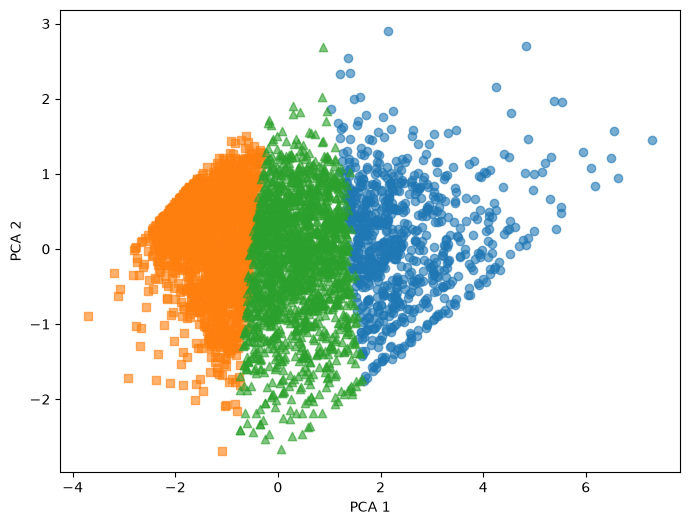

In [16]:
marker0 = rfm[rfm["Cluster"] == 0].index
marker1 = rfm[rfm["Cluster"] == 1].index
marker2 = rfm[rfm["Cluster"] == 2].index

plt.figure(figsize = (8, 6))
plt.scatter(x = rfm.loc[marker0, "pca_1"],
            y = rfm.loc[marker0, "pca_2"],
            marker = "o",
            label='Cluster 0',
            alpha=0.6)

plt.scatter(x = rfm.loc[marker1, "pca_1"],
            y = rfm.loc[marker1, "pca_2"],
            marker = "s",
            label='Cluster 1',
            alpha=0.6)

plt.scatter(x = rfm.loc[marker2, "pca_1"],
            y = rfm.loc[marker2, "pca_2"],
            marker = "^",
            label='Cluster 2',
            alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

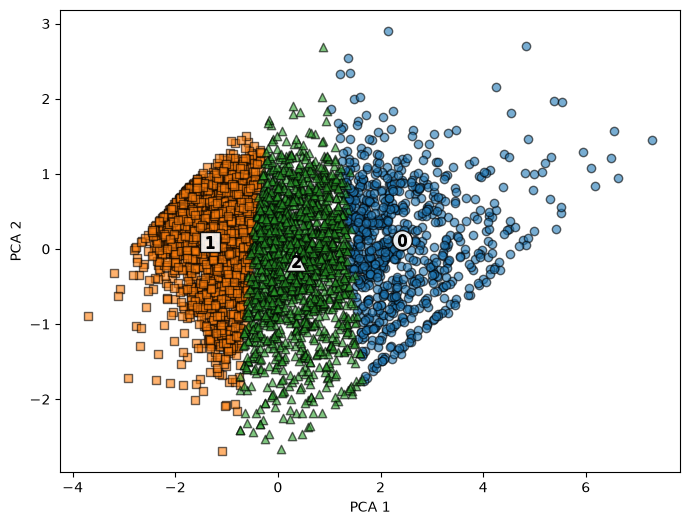

In [18]:
centers_original = kmeans.cluster_centers_
centers = pca.transform(centers_original)

unique_labels = np.unique(rfm["Cluster"])
markers = ["o", "s", "^", "P", "D", "H", "x"]

plt.figure(figsize=(8, 6))

for label in unique_labels:
    label_cluster = rfm[rfm["Cluster"] == label]
    center = centers[label]

    plt.scatter(x = label_cluster["pca_1"],
                y = label_cluster["pca_2"],
                edgecolor = "k", 
                alpha = 0.6,
                marker = markers[label]
                )
    plt.scatter(x = center[0], 
                y = center[1], 
                s = 200,
                color = "white", 
                alpha = 0.9, 
                edgecolor = "k",
                marker = markers[label])
    
    plt.scatter(x = center[0],
                y = center[1],
                s = 70,
                color = "k",
                edgecolor = "k",
                marker = "$%d$" % label)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()